# Question 1 Part (A)

## Reading the DataSet into a DataFrame, setting learning rate, and initialising thetas

In [1]:


import pandas as pd
df = pd.read_fwf("DataX.dat", names = ["Living Area", "Number of Bedrooms", "Number of Floors"])
df


m = df.shape[0]
m

theta0 = 0.25
theta1 = 0.5
theta2 = 0.75
theta3 = 1

learningRate = 0.00000025
#learningRate = 0.02

df.head()

,Living Area,Number of Bedrooms,Number of Floors
0,2104.0,3.0,2.0
1,1600.0,3.0,2.0
2,2400.0,3.0,2.0
3,1416.0,2.0,1.0
4,3000.0,4.0,3.0


In [2]:
data = {"x0": [1 for i in range(50)],"x1":df["Living Area"] ,"x2":df["Number of Bedrooms"], "x3":df["Number of Floors"]}
df2 = pd.DataFrame(data)
df2.head()



,x0,x1,x2,x3
0,1,2104.0,3.0,2.0
1,1,1600.0,3.0,2.0
2,1,2400.0,3.0,2.0
3,1,1416.0,2.0,1.0
4,1,3000.0,4.0,3.0


## Adding Target variable also into the DataFrame

In [3]:
targets = pd.read_csv("DataY.dat", names = ["y"])
targets

df2['y'] = targets['y']
df2.head()

,x0,x1,x2,x3,y
0,1,2104.0,3.0,2.0,399900.0
1,1,1600.0,3.0,2.0,329900.0
2,1,2400.0,3.0,2.0,369000.0
3,1,1416.0,2.0,1.0,232000.0
4,1,3000.0,4.0,3.0,539900.0


## Generating Predictions and Error

In [4]:
component1 = []
for i in range(m):
    component1.append(df2.iloc[i]['x0']*theta0)

component2 = []
for i in range(m):
    component2.append(df2.iloc[i]['x1']*theta1)

component3 = []
for i in range(m):
    component3.append(df2.iloc[i]['x2']*theta2)

component4 = []
for i in range(m):
    component4.append(df2.iloc[i]['x3']*theta3)




In [5]:
predictions = []
for i in range(m):
     predictions.append(component1[i] + component2[i] + component3[i] + component4[i])

df2['predictions'] = predictions

df2['h(x)-y'] = df2['predictions'] - df2['y']

df2.head()


,x0,x1,x2,x3,y,predictions,h(x)-y
0,1,2104.0,3.0,2.0,399900.0,1056.50,-398843.50
1,1,1600.0,3.0,2.0,329900.0,804.50,-329095.50
2,1,2400.0,3.0,2.0,369000.0,1204.50,-367795.50
3,1,1416.0,2.0,1.0,232000.0,710.75,-231289.25
4,1,3000.0,4.0,3.0,539900.0,1506.25,-538393.75


In [6]:
def generatePredictionAndError(df, theta0, theta1, theta2, theta3):

    df['predictions'] = theta0 * df['x0'] + theta1 * df['x1'] + theta2 * df['x2'] + theta3 * df['x3']

    df['h(x)-y'] = df['predictions'] - df['y']
    
    return df

## Applying Gradient Descent w.r.t. Mean Square Error as the cost function to update thetas

In [7]:
#Mean Square Error (MSE)

print("ORIGINAL DATAFRAME: ")
print(df2.head())

originalDF=df2

print("Original Theta 0: ", theta0)
print("Original Theta 1: ", theta1)
print("Original Theta 2: ", theta2)
print("Original Theta 3: ", theta3)

for i in range(10):
    theta0 = theta0 - (learningRate/m)*(df2['h(x)-y']*df2['x0']).sum()
    theta1 = theta1 - (learningRate/m)*(df2['h(x)-y']*df2['x1']).sum()
    theta2 = theta2 - (learningRate/m)*(df2['h(x)-y']*df2['x2']).sum()
    theta3 = theta3 - (learningRate/m)*(df2['h(x)-y']*df2['x3']).sum()

    df2 = generatePredictionAndError(df2, theta0, theta1, theta2, theta3)

print("Updated Theta 0: ", theta0)
print("Updated Theta 1: ", theta1)
print("Updated Theta 2: ", theta2)
print("Updated Theta 3: ", theta3)

print("FINAL DATAFRAME: ")
print(df2.head())




ORIGINAL DATAFRAME: 
   x0      x1   x2   x3         y  predictions     h(x)-y
0   1  2104.0  3.0  2.0  399900.0      1056.50 -398843.50
1   1  1600.0  3.0  2.0  329900.0       804.50 -329095.50
2   1  2400.0  3.0  2.0  369000.0      1204.50 -367795.50
3   1  1416.0  2.0  1.0  232000.0       710.75 -231289.25
4   1  3000.0  4.0  3.0  539900.0      1506.25 -538393.75
Original Theta 0:  0.25
Original Theta 1:  0.5
Original Theta 2:  0.75
Original Theta 3:  1
Updated Theta 0:  0.3459388517010255
Updated Theta 1:  162.66536709667082
Updated Theta 2:  1.036078510225556
Updated Theta 3:  1.1894843959582233
FINAL DATAFRAME: 
   x0      x1   x2   x3         y    predictions        h(x)-y
0   1  2104.0  3.0  2.0  399900.0  342253.765515 -57646.234485
1   1  1600.0  3.0  2.0  329900.0  260270.420498 -69629.579502
2   1  2400.0  3.0  2.0  369000.0  390402.714175  21402.714175
3   1  1416.0  2.0  1.0  232000.0  230337.767389  -1662.232611
4   1  3000.0  4.0  3.0  539900.0  488004.159996 -51895.840

## VISUALISING DATASET W.R.T. ORIGNAL TARGET VALUES AND PREDICTIONS

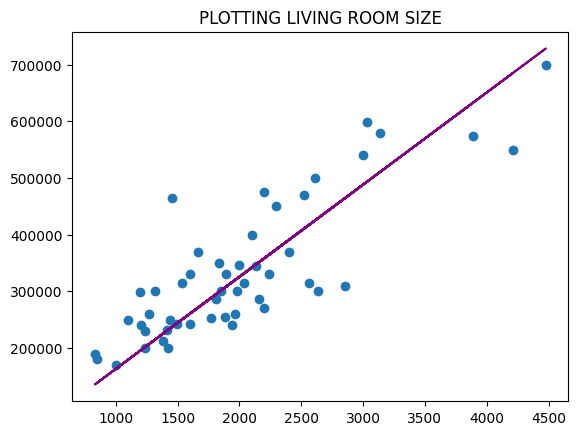

In [8]:
import matplotlib.pyplot as plt

plt.title("PLOTTING LIVING ROOM SIZE")
plt.scatter(df2["x1"], df2["y"])
plt.plot(df2["x1"], df2["predictions"], color = "purple")

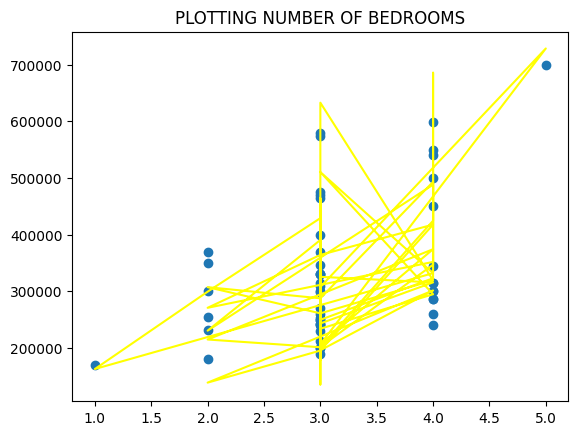

In [9]:

plt.title("PLOTTING NUMBER OF BEDROOMS")
plt.scatter(df2["x2"], df2["y"])
plt.plot(df2["x2"], df2["predictions"], color = "yellow")

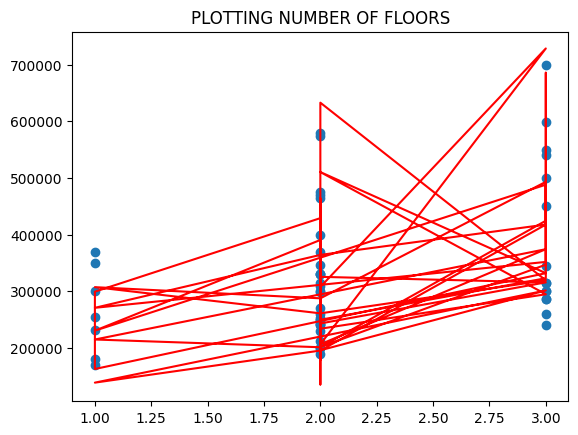

In [10]:
plt.title("PLOTTING NUMBER OF FLOORS")
plt.scatter(df2["x3"], df2["y"])
plt.plot(df2["x3"], df2["predictions"], color = "red")

## Discussion on results

In my opinion, as seen by the visualisations of each parameter of the dataset. The parameter, "living room size", accurately represents the target variable in contrast to the other two: "Number of bedrooms" and "Number of Floors". Therefore, we can see that the best fit line is able to map the training examples onto the target variable efficiently leading to a decent model. It is important to also note that the learning rate instructed to us, 0.02 does not fit properly for this model as the results of that is irregular regression. However, through test and trail it was seen that the learning rate or alpha for this model that is better happens to be quite low i.e. 0.0000000025. 

# Question 1 Part (B)

## The Initial DataFrame

In [11]:
df.head()

,Living Area,Number of Bedrooms,Number of Floors
0,2104.0,3.0,2.0
1,1600.0,3.0,2.0
2,2400.0,3.0,2.0
3,1416.0,2.0,1.0
4,3000.0,4.0,3.0


In [12]:
data = {"x0": [1 for i in range(50)],"x1":df["Living Area"] ,"x2":df["Number of Bedrooms"], "x3":df["Number of Floors"]}
df2 = pd.DataFrame(data)
df2.head()


,x0,x1,x2,x3
0,1,2104.0,3.0,2.0
1,1,1600.0,3.0,2.0
2,1,2400.0,3.0,2.0
3,1,1416.0,2.0,1.0
4,1,3000.0,4.0,3.0


## Adding Target variable also into the DataFrame

In [13]:
targets = pd.read_csv("DataY.dat", names = ["y"])
targets

df2['y'] = targets['y']
df2.head()

,x0,x1,x2,x3,y
0,1,2104.0,3.0,2.0,399900.0
1,1,1600.0,3.0,2.0,329900.0
2,1,2400.0,3.0,2.0,369000.0
3,1,1416.0,2.0,1.0,232000.0
4,1,3000.0,4.0,3.0,539900.0


## Generating Predictions and Error

In [14]:
theta0 = 0.25
theta1 = 0.5
theta2 = 0.75
theta3 = 1

component1 = []
for i in range(m):
    component1.append(df2.iloc[i]['x0']*theta0)

component2 = []
for i in range(m):
    component2.append(df2.iloc[i]['x1']*theta1)

component3 = []
for i in range(m):
    component3.append(df2.iloc[i]['x2']*theta2)

component4 = []
for i in range(m):
    component4.append(df2.iloc[i]['x3']*theta3)




In [15]:
predictions = []
for i in range(m):
     predictions.append(component1[i] + component2[i] + component3[i] + component4[i])

df2['predictions'] = predictions

df2['h(x)-y'] = df2['predictions'] - df2['y']

df2.head()


,x0,x1,x2,x3,y,predictions,h(x)-y
0,1,2104.0,3.0,2.0,399900.0,1056.50,-398843.50
1,1,1600.0,3.0,2.0,329900.0,804.50,-329095.50
2,1,2400.0,3.0,2.0,369000.0,1204.50,-367795.50
3,1,1416.0,2.0,1.0,232000.0,710.75,-231289.25
4,1,3000.0,4.0,3.0,539900.0,1506.25,-538393.75


In [16]:
def generatePredictionAndError(df, theta0, theta1, theta2, theta3):

    df['predictions'] = theta0 * df['x0'] + theta1 * df['x1'] + theta2 * df['x2'] + theta3 * df['x3']

    df['h(x)-y'] = df['predictions'] - df['y']
    
    return df

In [17]:
import numpy as np

df2.head()



,x0,x1,x2,x3,y,predictions,h(x)-y
0,1,2104.0,3.0,2.0,399900.0,1056.50,-398843.50
1,1,1600.0,3.0,2.0,329900.0,804.50,-329095.50
2,1,2400.0,3.0,2.0,369000.0,1204.50,-367795.50
3,1,1416.0,2.0,1.0,232000.0,710.75,-231289.25
4,1,3000.0,4.0,3.0,539900.0,1506.25,-538393.75


## Updating thetas through closed form solution

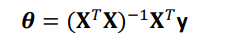

In [18]:
def makeTranspose(x, y, df2, m):
    transpose = {}
    
    for i in range(m):
        transpose[i] = []
    
    for i in range(m):
        for j in df2.columns[0:4]:
             transpose[i].append(df2[j].iloc[i])
    
    
    transpose = pd.DataFrame(transpose, index = df2.columns[0:4])
    xt = transpose
    return xt

## Sir Agreed in the lecture to allow numpy builtin functions for matrix multiplication and inverse etc.

In [19]:
def closedFormSolution(x, y):
    test = np.dot(xt,x) 
    test = np.linalg.pinv(test)
    test = np.dot(test, xt)
    test = np.dot(test, y)
    return test

## APPLYING GRADIENT DESCENT

In [20]:
#Mean Square Error (MSE)


x = df2[df2.columns[0:4]]
y = df2[['y']]

xt = makeTranspose(x,y,df2,m)

originalDF=df2
print("ORIGIANAL DATAFRAME: ")
print(df2.head())

print("Original Theta 0: ", theta0)
print("Original Theta 1: ", theta1)
print("Original Theta 2: ", theta2)
print("Original Theta 3: ", theta3)

for i in range(10):    

    updatedThetas = closedFormSolution(x,y)    
    theta0 =  updatedThetas[0][0]
    theta1 =  updatedThetas[1][0]
    theta2 =  updatedThetas[2][0]
    theta3 =  updatedThetas[3][0]
    df2 = generatePredictionAndError(df2, theta0, theta1, theta2, theta3)  

print("FINAL DATAFRAME")
print(df2.head())

print("Updated Theta 0: ", theta0)
print("Updated Theta 1: ", theta1)
print("Updated Theta 2: ", theta2)
print("Updated Theta 3: ", theta3)






ORIGIANAL DATAFRAME: 
   x0      x1   x2   x3         y  predictions     h(x)-y
0   1  2104.0  3.0  2.0  399900.0      1056.50 -398843.50
1   1  1600.0  3.0  2.0  329900.0       804.50 -329095.50
2   1  2400.0  3.0  2.0  369000.0      1204.50 -367795.50
3   1  1416.0  2.0  1.0  232000.0       710.75 -231289.25
4   1  3000.0  4.0  3.0  539900.0      1506.25 -538393.75
Original Theta 0:  0.25
Original Theta 1:  0.5
Original Theta 2:  0.75
Original Theta 3:  1
FINAL DATAFRAME
   x0      x1   x2   x3         y    predictions        h(x)-y
0   1  2104.0  3.0  2.0  399900.0  350446.638190 -49453.361810
1   1  1600.0  3.0  2.0  329900.0  286128.193195 -43771.806805
2   1  2400.0  3.0  2.0  369000.0  388220.963028  19220.963028
3   1  1416.0  2.0  1.0  232000.0  272608.982713  40608.982713
4   1  3000.0  4.0  3.0  539900.0  454828.413824 -85071.586176
Updated Theta 0:  48828.93853016055
Updated Theta 1:  127.6159622909969
Updated Theta 2:  53037.96815726688
Updated Theta 3:  -63000.09473621168

## VISUALISING DATASET W.R.T. ORIGNAL TARGET VALUES AND PREDICTIONS

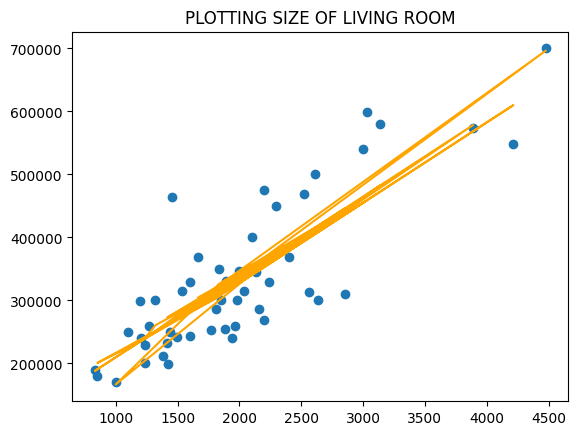

In [21]:
import matplotlib.pyplot as plt

plt.title("PLOTTING SIZE OF LIVING ROOM")
plt.scatter(df2["x1"], df2["y"])
plt.plot(df2["x1"], df2["predictions"], color = "orange")

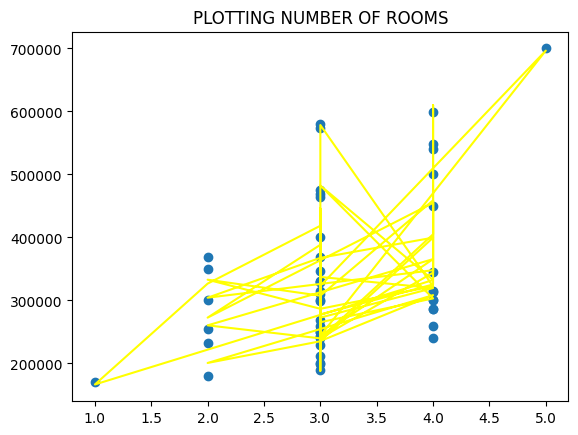

In [22]:
plt.title("PLOTTING NUMBER OF ROOMS")
plt.scatter(df2["x2"], df2["y"])
plt.plot(df2["x2"], df2["predictions"], color = "yellow")

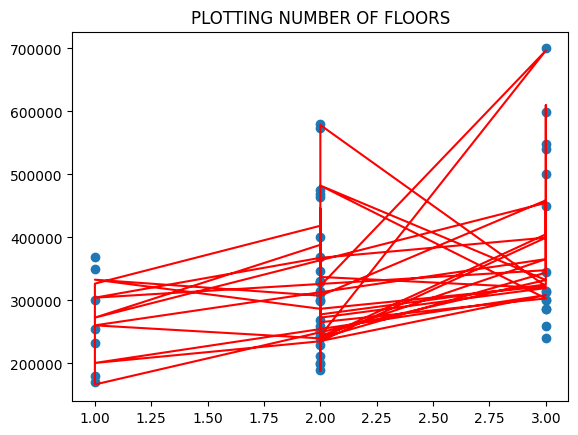

In [23]:
plt.title("PLOTTING NUMBER OF FLOORS")
plt.scatter(df2["x3"], df2["y"])
plt.plot(df2["x3"], df2["predictions"], color = "red")

## Discussion on results

As seen through the visulisations, it is seen that the the closed form solution method did not work as adaptable for the dataset as it was in the case of part (a). However, we can still conclude that the parameter, "Size of living room", is still a better parameter to have major impact on the target variable. The other two behave in a similar manner as seen before which is due to their inability to justify efficiently the target variable, thus, causing an irregular pattern of plot.

## COMPARISONS

In both cases, "living room size" is consistently identified as the most impactful parameter on the target variable, producing better model predictions compared to "Number of bedrooms" and "Number of floors."

**PART A:** 

The results show that "living room size" leads to a decent model fit, with the best fit line effectively mapping the training examples to the target variable. However, the initially instructed learning rate (0.02) caused irregular results, and a smaller learning rate was found to improve performance.

**PART B:**

Although the closed form solution was less adaptable for this dataset, "living room size" still proved to be the best predictor of the target variable. The other parameters showed similar inefficiency as in case 1, leading to irregular plotting patterns.

***In summary, both cases demonstrate the significance of "living room size" in model performance, but the method in case 1 produced better overall results.***

## QUESTION 2

In [24]:
import pandas as pd
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(1)**-z)

def generate_predictions(df, theta0, theta1, theta2, theta3):
    df['predictions'] = df["x0"]*theta0 + df["x1"]*theta1 + df["x2"]*theta2 + df["x3"]*theta3
    df['probabilities'] = sigmoid(df['predictions'])  # Apply the sigmoid function
    return df

def sgd(df, targets, theta0, theta1, theta2, theta3, learning_rate):
    m = len(df)  # Number of data points

    for i in range(m):
        prediction = df['probabilities'].iloc[i]
        error = prediction - targets[i]
        
        theta0 -= learning_rate * error * df['x0'].iloc[i]
        theta1 -= learning_rate * error * df['x1'].iloc[i]
        theta2 -= learning_rate * error * df['x2'].iloc[i]
        theta3 -= learning_rate * error * df['x3'].iloc[i]

    return theta0, theta1, theta2, theta3


In [25]:

df = pd.read_fwf("DataX.dat", names=["x1", "x2", "x3"])
df["x0"] = 1  # Adding bias term for theta0


class_y = pd.read_fwf("ClassY.dat", names=["y"])

df["y"] = class_y['y']

theta0 = 0.25
theta1 = 0.5
theta2 = 0.75
theta3 = 1

learning_rate = 0.02

print("ORIGINAL DATAFRAME: \n", df)

df[["x1", "x2", "x3"]] = (df[["x1", "x2", "x3"]] - df[["x1", "x2", "x3"]].mean()) / df[["x1", "x2", "x3"]].std()


print("ORIGINAL THETA0: ", theta0)
print("ORIGINAL THETA1: ", theta1)
print("ORIGINAL THETA2: ", theta2)
print("ORIGINAL THETA3: ", theta3)

iterations = 100  # Number of iterations to run SGD
for iteration in range(iterations):
    df = generate_predictions(df, theta0, theta1, theta2, theta3)  # Generate predictions
    theta0, theta1, theta2, theta3 = sgd(df, class_y['y'], theta0, theta1, theta2, theta3, learning_rate)




print("UPDATED THETA0: ", theta0)
print("UPDATED THETA1: ", theta1)
print("UPDATED THETA2: ", theta2)
print("UPDATED THETA3: ", theta3)

final_predictions = []

for prob in df['probabilities']:
    if prob >= 0.5:
        final_predictions.append(1)

    else:
        final_predictions.append(0)


df['final_prediction'] = final_predictions

'''for i in range(df.shape[0]):
    if(df['probabilities'].iloc[i] <= 0.5):
        df['final_prediction'] = 'not costly'

    else:
        df['final_prediction'] = 'costly'''
    
print("UPDATED DATAFRAME: \n", df)

ORIGINAL DATAFRAME: 
         x1   x2   x3  x0  y
0   2104.0  3.0  2.0   1  1
1   1600.0  3.0  2.0   1  1
2   2400.0  3.0  2.0   1  1
3   1416.0  2.0  1.0   1  0
4   3000.0  4.0  3.0   1  1
5   1985.0  4.0  3.0   1  0
6   1534.0  3.0  2.0   1  1
7   1427.0  3.0  2.0   1  0
8   1380.0  3.0  2.0   1  1
9   1494.0  3.0  2.0   1  1
10  1940.0  4.0  3.0   1  1
11  2000.0  3.0  2.0   1  0
12  1890.0  3.0  2.0   1  0
13  4478.0  5.0  3.0   1  0
14  1268.0  3.0  2.0   1  1
15  2300.0  4.0  3.0   1  0
16  1320.0  2.0  1.0   1  1
17  1236.0  3.0  2.0   1  1
18  2609.0  4.0  3.0   1  0
19  3031.0  4.0  3.0   1  1
20  1767.0  3.0  2.0   1  0
21  1888.0  2.0  1.0   1  1
22  1604.0  3.0  2.0   1  1
23  1962.0  4.0  3.0   1  1
24  3890.0  3.0  2.0   1  0
25  1100.0  3.0  2.0   1  1
26  1458.0  3.0  2.0   1  0
27  2526.0  3.0  2.0   1  1
28  2200.0  3.0  2.0   1  1
29  2637.0  3.0  2.0   1  1
30  1839.0  2.0  1.0   1  1
31  1000.0  1.0  1.0   1  0
32  2040.0  4.0  3.0   1  0
33  3137.0  3.0  2.0   1  